# Imports

In [1]:
import pandas as pd

# Clearing
from datetime import datetime
import re

# EDA
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('data/transactions.csv')
df.head()

,sender_id,receiver_id,date,amount_kzt,description,doc_type
0,341113577953,421128527724,2024-10-05,18579.93,"Поставка канцелярских товаров (бумага А4, ручк...",INVOICE
1,950908633188,821120551797,2025-07-29,1706226.33,Поставка медикаментов по списку,INVOICE
2,500817613929,830425668259,2025/05/17,286266.87,"СИЗ: перчатки, очки, респираторы",INVOICE
3,110824699080,220312376061,2024-02-08,996569.04,Грузоперевозка щебня по г. Алматы,INVOICE
4,910816595223,110910187697,20/10/2024,120351.41,ГСМ за февраль 2025,INVOICE


# Base lookup

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80800 entries, 0 to 80799
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sender_id    80800 non-null  object 
 1   receiver_id  80800 non-null  object 
 2   date         80800 non-null  object 
 3   amount_kzt   80800 non-null  float64
 4   description  79953 non-null  object 
 5   doc_type     80800 non-null  object 
dtypes: float64(1), object(5)
memory usage: 3.7+ MB


In [4]:
df.shape

(80800, 6)

In [5]:
df.describe()

,amount_kzt
count,8.080000e+04
mean,2.054052e+06
std,3.633813e+06
min,-1.493393e+07
25%,4.609458e+04
50%,3.240972e+05
75%,2.189493e+06
max,1.499862e+07


In [6]:
df.describe(include=['object'])

,sender_id,receiver_id,date,description,doc_type
count,80800,80800,80800,79953,80800
unique,6140,6099,3404,28230,3
top,170915651329,551211641020,2024-12-28,Жүк тасымалдау қызметтері Алматы-Ақтөбе,INVOICE
freq,329,144,62,1161,48530


In [7]:
df.isna().sum()

sender_id        0
receiver_id      0
date             0
amount_kzt       0
description    847
doc_type         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(800)

---

# Clearing part

In [9]:
# ISO 8601 date format
df_clean = df.copy()
df_clean['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

df_clean['date']

0       2024-10-05
1       2025-07-29
2       2025-05-17
3       2024-02-08
4       2024-10-20
           ...    
80795   2024-06-15
80796   2025-11-11
80797   2024-12-30
80798   2025-10-28
80799   2026-04-13
Name: date, Length: 80800, dtype: datetime64[ns]

In [10]:
# Validation of IIN
def clear_id(str_id):
    """
    чистка иин от символов и пробелов
    """
    str_id = str(str_id).replace(' ', '').replace('-', '')
    str_id = str(str_id).replace('I', '1').replace('O', '0')
    str_id = re.sub(r'[^0-9]', '', str_id)
    
    return str_id

df_clean['sender_id'] = df_clean['sender_id'].apply(clear_id)
df_clean['receiver_id'] = df_clean['receiver_id'].apply(clear_id)


def validate_checksum_rk(bin_iin):
    """
    контрольная сумма по алгоритму РК
    """
    if not isinstance(bin_iin, str) or len(bin_iin) != 12 or not bin_iin.isdigit():
          return False

    weights1 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
    weights2 = [3, 4, 5, 6, 7, 8, 9, 10, 11, 1, 2]

    digits = [int(d) for d in bin_iin[:11]]
    control_digit = int(bin_iin[11])

    checksum1 = sum(d * w for d, w in zip(digits, weights1)) % 11

    if checksum1 == 10:
        checksum2 = sum(d * w for d, w in zip(digits, weights2)) % 11
        return checksum2 != 10 and checksum2 == control_digit

    return checksum1 == control_digit

df_clean['sender_valid'] = df_clean['sender_id'].apply(validate_checksum_rk)
df_clean['receiver_valid'] = df_clean['receiver_id'].apply(validate_checksum_rk)
df_clean['both_valid_id'] = df_clean['sender_valid'] & df_clean['receiver_valid']

df_clean['sender_valid'] = df_clean['sender_valid'].astype(int)
df_clean['receiver_valid'] = df_clean['receiver_valid'].astype(int)
df_clean['both_valid_id'] = df_clean['both_valid_id'].astype(int)

df_clean['both_valid_id'].value_counts()

df_clean['receiver_valid'].value_counts()
df_clean['sender_valid'].value_counts()



sender_valid
1    80389
0      411
Name: count, dtype: int64

In [11]:
df_clean[df_clean['amount_kzt'] == 66961.46] 

,sender_id,receiver_id,date,amount_kzt,description,doc_type,sender_valid,receiver_valid,both_valid_id
61894,090514503662,080421521108,2025-11-15,66961.46,Семинар по охране труда,INVOICE,1,1,1


In [12]:
df_clean.shape

(80800, 9)

In [13]:
# Drop Duplicates
print('The size of dataset with duplicates:',len(df))

df_clean = df_clean.drop_duplicates(keep='first')

print('The size of dataset without full duplicates:',len(df_clean))
print('Dropped:', len(df) - len(df_clean), 'rows')

df_clean = df_clean.drop_duplicates(
      subset=['sender_id', 'receiver_id', 'date', 'amount_kzt', 'description'],
      keep='first'
)
print('After droping duplicates with primarly columns',len(df_clean))

print('Totally dropped:', len(df) - len(df_clean))



The size of dataset with duplicates: 80800
The size of dataset without full duplicates: 80000
Dropped: 800 rows
After droping duplicates with primarly columns 80000
Totally dropped: 800


In [14]:
# Drop Null Description values
print('Null description values size:',df_clean['description'].isna().sum())
print(df_clean['description'].isna().sum() / len(df_clean),'%')

# Dropping null values
df_clean.dropna(inplace = True)
print('The size of dataset after dropping null values:',len(df_clean))



Null description values size: 836
0.01045 %
The size of dataset after dropping null values: 79164


**The null values size with comparing of full dataset size is 1.045% which is to small to fill, but filling this column is creates a poor eavluation quality**

### The result of clearing part

In [15]:
print('='*80)
print('DATA CLEANING REPORT')
print('='*80)
print('\nDataset before:')
print(df.head())
print('-'*80)
print('\nDataset after:')
print(df_clean.head())
print('-'*80)
print('\nCleaning Summary:')
print(f"Total rows before: {len(df)}")
print(f"Total rows after: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")
print('-'*80)
print('\nMissing Values:')
print(f"Missing description before: {df['description'].isna().sum()} ({df['description'].isna().sum()/len(df)*100:.2f}%)")
print(f"Missing description after: {df_clean['description'].isna().sum()} ({df_clean['description'].isna().sum()/len(df)*100:.2f}%)")
print('-'*80)
print('\nDuplicates:')
print(f"Duplicates before: {df.duplicated().sum()} ({df.duplicated().sum()/len(df)*100:.2f}%)")
print(f"Duplicates after: {df_clean.duplicated().sum()} ({df_clean.duplicated().sum()/len(df_clean)*100:.2f}%)")
print('-'*80)
print('\nIIN/BIN Validation:')
print(f"Valid sender_id: {df_clean['sender_valid'].sum()} ({df_clean['sender_valid'].sum()/len(df)*100:.2f}%)")
print(f"Valid receiver_id: {df_clean['receiver_valid'].sum()} ({df_clean['receiver_valid'].sum()/len(df)*100:.2f}%)")
print(f"Both IDs valid: {df_clean['both_valid_id'].sum()} ({df_clean['both_valid_id'].sum()/len(df)*100:.2f}%)")
print(f"The IIN validation handled: {len(df_clean[df_clean['both_valid_id'] == True]) / len(df)*100:.2f}% of original dataset")
print('='*80)

DATA CLEANING REPORT

Dataset before:
      sender_id   receiver_id        date  amount_kzt  \
0  341113577953  421128527724  2024-10-05    18579.93   
1  950908633188  821120551797  2025-07-29  1706226.33   
2  500817613929  830425668259  2025/05/17   286266.87   
3  110824699080  220312376061  2024-02-08   996569.04   
4  910816595223  110910187697  20/10/2024   120351.41   

                                         description doc_type  
0  Поставка канцелярских товаров (бумага А4, ручк...  INVOICE  
1                    Поставка медикаментов по списку  INVOICE  
2                   СИЗ: перчатки, очки, респираторы  INVOICE  
3                  Грузоперевозка щебня по г. Алматы  INVOICE  
4                                ГСМ за февраль 2025  INVOICE  
--------------------------------------------------------------------------------

Dataset after:
      sender_id   receiver_id       date  amount_kzt  \
0  341113577953  421128527724 2024-10-05    18579.93   
1  950908633188  821120551

---

# EDA

In [16]:
print('Shape of dataset:', df_clean.shape)
print('-'*80)

print('Date range:', df_clean['date'].min(), 'to', df_clean['date'].max())
print('-'*80)

print(f"Period: {(df_clean['date'].max() - df_clean['date'].min()).days} days")
print('-'*80)

print(f"Unique senders: {df_clean[df_clean['sender_valid'] == 1]['sender_id'].nunique()}")
print('-'*80)

print(f"Unique receivers: {df_clean[df_clean['receiver_valid'] == 1]['receiver_id'].nunique()}")
print('-'*80)

print(f"Unique descriptions: {df_clean['description'].nunique():,}")
print('-'*80)

print(f"Document types: {df_clean['doc_type'].unique()}")


Shape of dataset: (79164, 9)
--------------------------------------------------------------------------------
Date range: 2024-01-01 00:00:00 to 2026-04-30 00:00:00
--------------------------------------------------------------------------------
Period: 850 days
--------------------------------------------------------------------------------
Unique senders: 5000
--------------------------------------------------------------------------------
Unique receivers: 5000
--------------------------------------------------------------------------------
Unique descriptions: 28,230
--------------------------------------------------------------------------------
Document types: ['INVOICE' 'WAYBILL' 'ACT']


In [17]:
print("Top-20 sender's")
top_senders = df_clean[df_clean['sender_valid'] == 1].groupby('sender_id')['amount_kzt'].agg(['sum', 'count']).sort_values('sum', ascending=False).head(20)
top_senders.columns = ['Total Amount (KZT)', 'Transaction Count']
print(top_senders)

Top-20 sender's
              Total Amount (KZT)  Transaction Count
sender_id                                          
720221554469        7.604863e+08                300
580811600403        7.289676e+08                291
181226594058        7.041292e+08                307
310909691346        7.041033e+08                299
170915651329        6.941766e+08                322
401110643824        6.888178e+08                299
140512557513        6.817327e+08                312
941101594315        6.663952e+08                308
970913552723        6.393789e+08                299
570328465547        6.225127e+08                291
460614400792        6.117068e+08                276
861218496740        5.948159e+08                278
450815601992        5.863394e+08                250
270122476708        5.840709e+08                284
750125644155        5.825853e+08                284
181120401530        5.792574e+08                315
371002684702        5.780415e+08                

In [18]:
print("Top-20 receiver's")
top_receivers = df_clean[df_clean['receiver_valid']==1].groupby('receiver_id')['amount_kzt'].agg(['sum', 'count']).sort_values('sum', ascending=False).head(20)
top_receivers.columns = ['Total Amount (KZT)', 'Transaction Count']
print(top_receivers)

Top-20 receiver's
              Total Amount (KZT)  Transaction Count
receiver_id                                        
850603506938        3.710884e+08                137
711020691210        3.610823e+08                143
410517502025        3.340649e+08                135
551211641020        3.338612e+08                143
730424495604        3.074363e+08                127
121125400846        2.941522e+08                136
850623490114        2.888279e+08                120
861228440096        2.690062e+08                130
990508519961        2.662536e+08                131
670603689146        2.648961e+08                122
740201661314        2.624295e+08                118
731211426100        2.562052e+08                135
870618658764        2.539863e+08                132
721125608037        2.522296e+08                114
080421521108        2.516351e+08                125
480218577728        2.493777e+08                112
900326509443        2.487870e+08              

Monthly dynamics
--------------------------------------------------------------------------------

Monthly statistics:
Year-Month  Total Amount   Avg Amount  Median Amount  Transaction Count
   2024-01  6.323366e+09 2.171486e+06     337635.480               2912
   2024-02  5.188857e+09 1.951432e+06     308740.940               2659
   2024-03  5.837590e+09 2.088583e+06     316128.940               2795
   2024-04  5.898411e+09 2.140984e+06     353087.500               2755
   2024-05  5.852257e+09 2.025703e+06     314825.900               2889
   2024-06  6.136481e+09 2.216136e+06     355679.140               2769
   2024-07  5.966360e+09 2.115730e+06     308551.895               2820
   2024-08  5.481988e+09 1.892952e+06     314347.180               2896
   2024-09  5.431212e+09 1.956489e+06     292311.205               2776
   2024-10  5.723512e+09 2.008955e+06     294286.120               2849
   2024-11  5.692290e+09 2.052755e+06     342443.740               2773
   2024-12  6.317

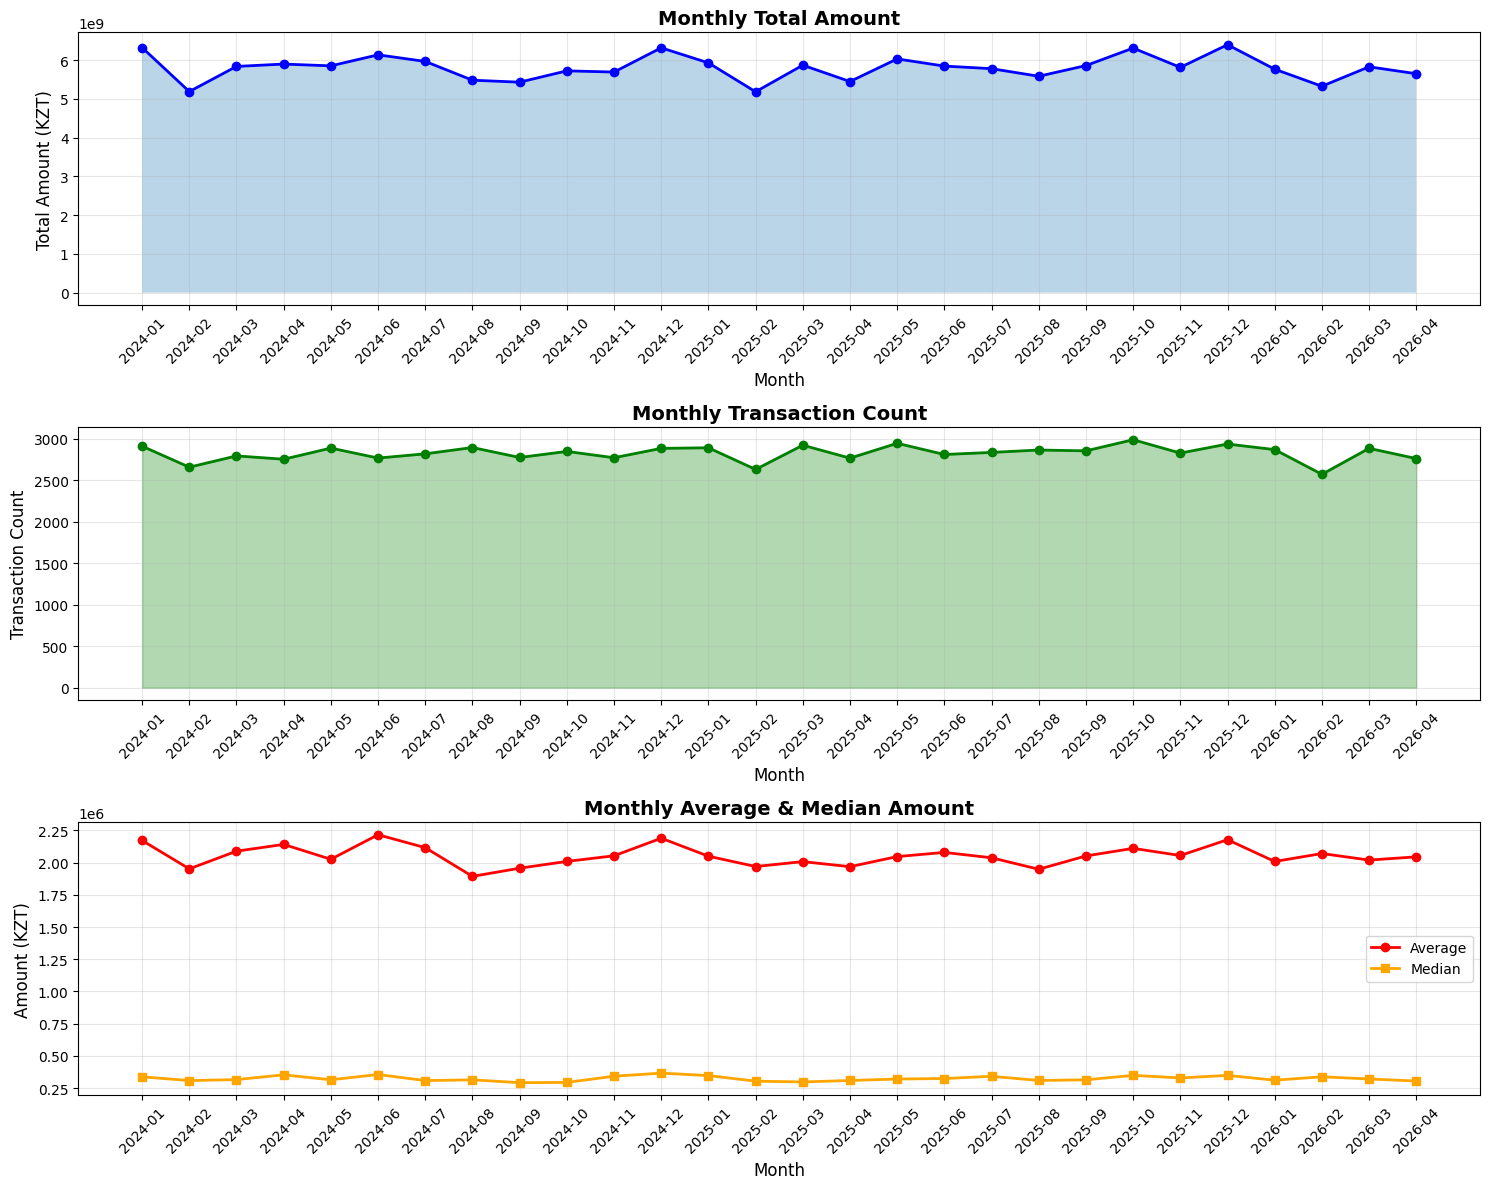

In [19]:
print('Monthly dynamics')
print('-'*80)
df_clean['year_month'] = df_clean['date'].dt.to_period('M')

  # Monthly aggregation
monthly_stats = df_clean.groupby('year_month').agg({
      'amount_kzt': ['sum', 'mean', 'median', 'count']
}).reset_index()
monthly_stats.columns = ['Year-Month', 'Total Amount', 'Avg Amount', 'Median Amount', 'Transaction Count']
monthly_stats['Year-Month'] = monthly_stats['Year-Month'].astype(str)

print("\nMonthly statistics:")
print(monthly_stats.to_string(index=False))

# Plot monthly dynamics
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Total amount by month
axes[0].plot(monthly_stats['Year-Month'], monthly_stats['Total Amount'], marker='o', color='blue', linewidth=2)
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Total Amount (KZT)', fontsize=12)
axes[0].set_title('Monthly Total Amount', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)
axes[0].fill_between(range(len(monthly_stats)), monthly_stats['Total Amount'], alpha=0.3)

# Transaction count by month
axes[1].plot(monthly_stats['Year-Month'], monthly_stats['Transaction Count'], marker='o', color='green', linewidth=2)
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Transaction Count', fontsize=12)
axes[1].set_title('Monthly Transaction Count', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)
axes[1].fill_between(range(len(monthly_stats)), monthly_stats['Transaction Count'], alpha=0.3, color='green')

# Average amount by month
axes[2].plot(monthly_stats['Year-Month'], monthly_stats['Avg Amount'], marker='o', color='red', linewidth=2, label='Average')
axes[2].plot(monthly_stats['Year-Month'], monthly_stats['Median Amount'], marker='s', color='orange', linewidth=2, label='Median')
axes[2].set_xlabel('Month', fontsize=12)
axes[2].set_ylabel('Amount (KZT)', fontsize=12)
axes[2].set_title('Monthly Average & Median Amount', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.savefig('images/monthly_dynamics.png', dpi=300, bbox_inches='tight')
print("Saved: images/monthly_dynamics.png")
plt.show()

Amount distirbution
--------------------------------------------------------------------------------

Amount statistics:
count    7.916400e+04
mean     2.052350e+06
std      3.631906e+06
min     -1.493393e+07
25%      4.612662e+04
50%      3.240972e+05
75%      2.187540e+06
max      1.499862e+07
Name: amount_kzt, dtype: float64

Negative amounts: 375 (0.47%)
Zero amounts: 0 (0.00%)
Positive amounts: 78789 (99.53%)
Saved: images/amount_distribution.png


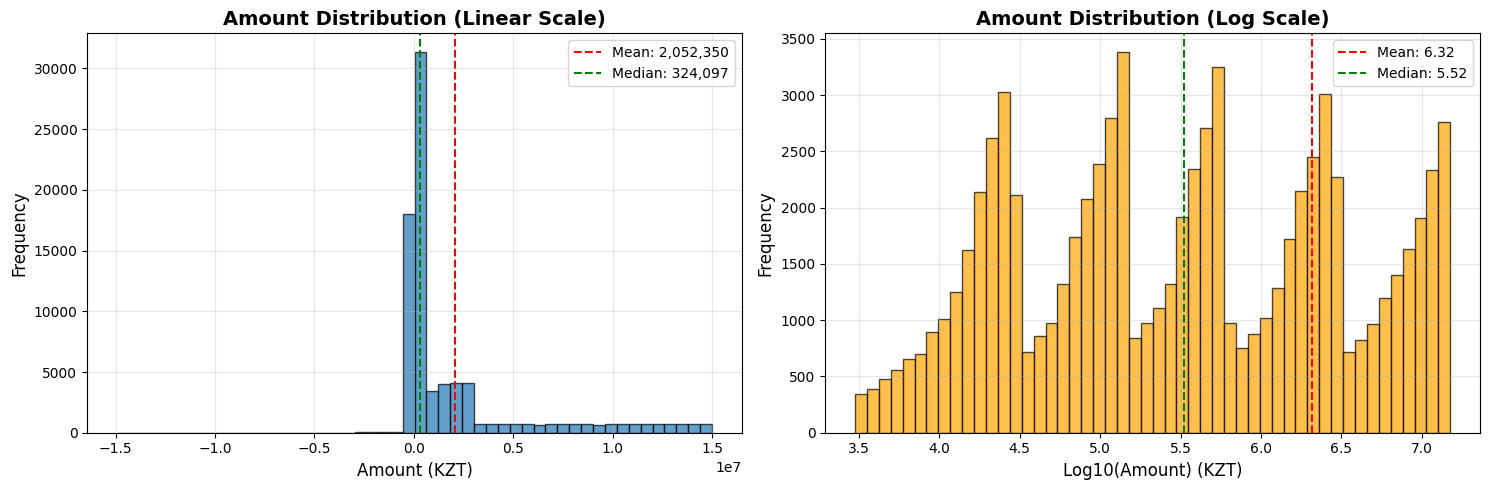

In [20]:
print('Amount distirbution')
print('-'*80)

print(f"\nAmount statistics:")
print(df_clean['amount_kzt'].describe())

print(f"\nNegative amounts: {(df_clean['amount_kzt'] < 0).sum()} ({(df_clean['amount_kzt'] < 0).sum()/len(df_clean)*100:.2f}%)")
print(f"Zero amounts: {(df_clean['amount_kzt'] == 0).sum()} ({(df_clean['amount_kzt'] == 0).sum()/len(df_clean)*100:.2f}%)")
print(f"Positive amounts: {(df_clean['amount_kzt'] > 0).sum()} ({(df_clean['amount_kzt'] > 0).sum()/len(df_clean)*100:.2f}%)")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Linear scale
axes[0].hist(df_clean['amount_kzt'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Amount (KZT)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Amount Distribution (Linear Scale)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(df_clean['amount_kzt'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["amount_kzt"].mean():,.0f}')
axes[0].axvline(df_clean['amount_kzt'].median(), color='green', linestyle='--', label=f'Median: {df_clean["amount_kzt"].median():,.0f}')
axes[0].legend()

# Log scale (only positive amounts)
positive_amounts = df_clean[df_clean['amount_kzt'] > 0]['amount_kzt']
axes[1].hist(np.log10(positive_amounts), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Log10(Amount) (KZT)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Amount Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(np.log10(positive_amounts.mean()), color='red', linestyle='--', label=f'Mean: {np.log10(positive_amounts.mean()):.2f}')
axes[1].axvline(np.log10(positive_amounts.median()), color='green', linestyle='--', label=f'Median: {np.log10(positive_amounts.median()):.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/amount_distribution.png', dpi=300, bbox_inches='tight')
print("Saved: images/amount_distribution.png")

In [21]:
print('Anomaly decetion')
print()
print('Anomaly 1')
print(len(df_clean[df_clean['amount_kzt'] < 0]))
print('Possible anomaly due to there can not be a negaitve income. Maybe something wrong with doc_type columns and this is not a Income/Waybill/Act')
print()


print('Anomaly 2')
sender_counts = df_clean[df_clean['sender_valid']==1]['sender_id'].value_counts()
scQ95 = sender_counts.quantile(0.95)
scQ99 = sender_counts.quantile(0.99)

suspect_active_senders = sender_counts[sender_counts > scQ95]
mean_active_sender = sender_counts.mean()
median_active_sender = sender_counts.median()
max_active_sender = sender_counts.max()

print(f"Average transactions per sender: {mean_active_sender}")
print(f"Median transactions per sender: {median_active_sender}")
print(f"95th percentile: {scQ95} transactions")
print(f"99th percentile: {scQ99} transactions")
print(f"Max transactions by one sender: {max_active_sender}")
print(f"Hyperactive senders (>95th percentile): {len(suspect_active_senders)}")
print('Possible anomaly because these senders a suspectfully active, and these actions can be a part of fraud')
print()


print('Anomaly 3')
amQ95 = df_clean['amount_kzt'].quantile(0.95)
amQ99 = df_clean['amount_kzt'].quantile(0.99)
suspect_amounts = df_clean[df_clean['amount_kzt'] > amQ99]
print(f"95th percentile: {amQ95} KZT")
print(f"99th percentile: {amQ99} KZT")
print(f"Max amount: {df_clean['amount_kzt'].max()} KZT")
print(f"Outliers (>99th percentile): {len(suspect_amounts)} ({len(suspect_amounts)/len(df_clean)*100}%)")
print(f"Total outlier amount: {suspect_amounts['amount_kzt'].sum()} KZT ({suspect_amounts['amount_kzt'].sum()/df_clean['amount_kzt'].sum()*100}% of total)")
print('Possible anomaly, because these amounts are a much more than a 95% of whole amounts. These actions might be part of money laundring or financial fraud')


Anomaly decetion

Anomaly 1
375
Possible anomaly due to there can not be a negaitve income. Maybe something wrong with doc_type columns and this is not a Income/Waybill/Act

Anomaly 2
Average transactions per sender: 15.7522
Median transactions per sender: 11.0
95th percentile: 18.0 transactions
99th percentile: 194.02000000000044 transactions
Max transactions by one sender: 322
Hyperactive senders (>95th percentile): 243
Possible anomaly because these senders a suspectfully active, and these actions can be a part of fraud

Anomaly 3
95th percentile: 11619757.647499958 KZT
99th percentile: 14344487.2984 KZT
Max amount: 14998616.42 KZT
Outliers (>99th percentile): 792 (1.0004547521600726%)
Total outlier amount: 11615068038.310001 KZT (7.148953949220628% of total)
Possible anomaly, because these amounts are a much more than a 95% of whole amounts. These actions might be part of money laundring or financial fraud


In [22]:
df_clean['description_clean'] = df_clean['description'].str.lower().str.strip()


In [23]:
df_clean.to_csv('data/transactions_cleaned.csv', index=False, encoding='utf-8')

print(f"Saved: data/transactions_cleaned.csv")
print(f"Rows: {len(df_clean)}")
print(f"Columns: {len(df_clean.columns)}")

Saved: data/transactions_cleaned.csv
Rows: 79164
Columns: 11
